In [31]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as pp
import seaborn as sb

In [32]:
project_path = Path.cwd()
data_path = project_path / 'data'
col_reduced_data_path = data_path / '02_reduced_columns'

In [33]:
df_toa = pd.read_parquet(col_reduced_data_path / 'df_in_toa_radiance.pqt')
df_aph = pd.read_parquet(col_reduced_data_path / 'df_aph.pqt')
df_chl = pd.read_parquet(col_reduced_data_path / 'df_chl.pqt')

Rayleigh-corrected radiance

In [34]:
df_toa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Rrc_412  495 non-null    float64
 1   Rrc_443  495 non-null    float64
 2   Rrc_490  495 non-null    float64
 3   Rrc_510  495 non-null    float64
 4   Rrc_555  495 non-null    float64
 5   Rrc_670  495 non-null    float64
dtypes: float64(6)
memory usage: 23.4 KB


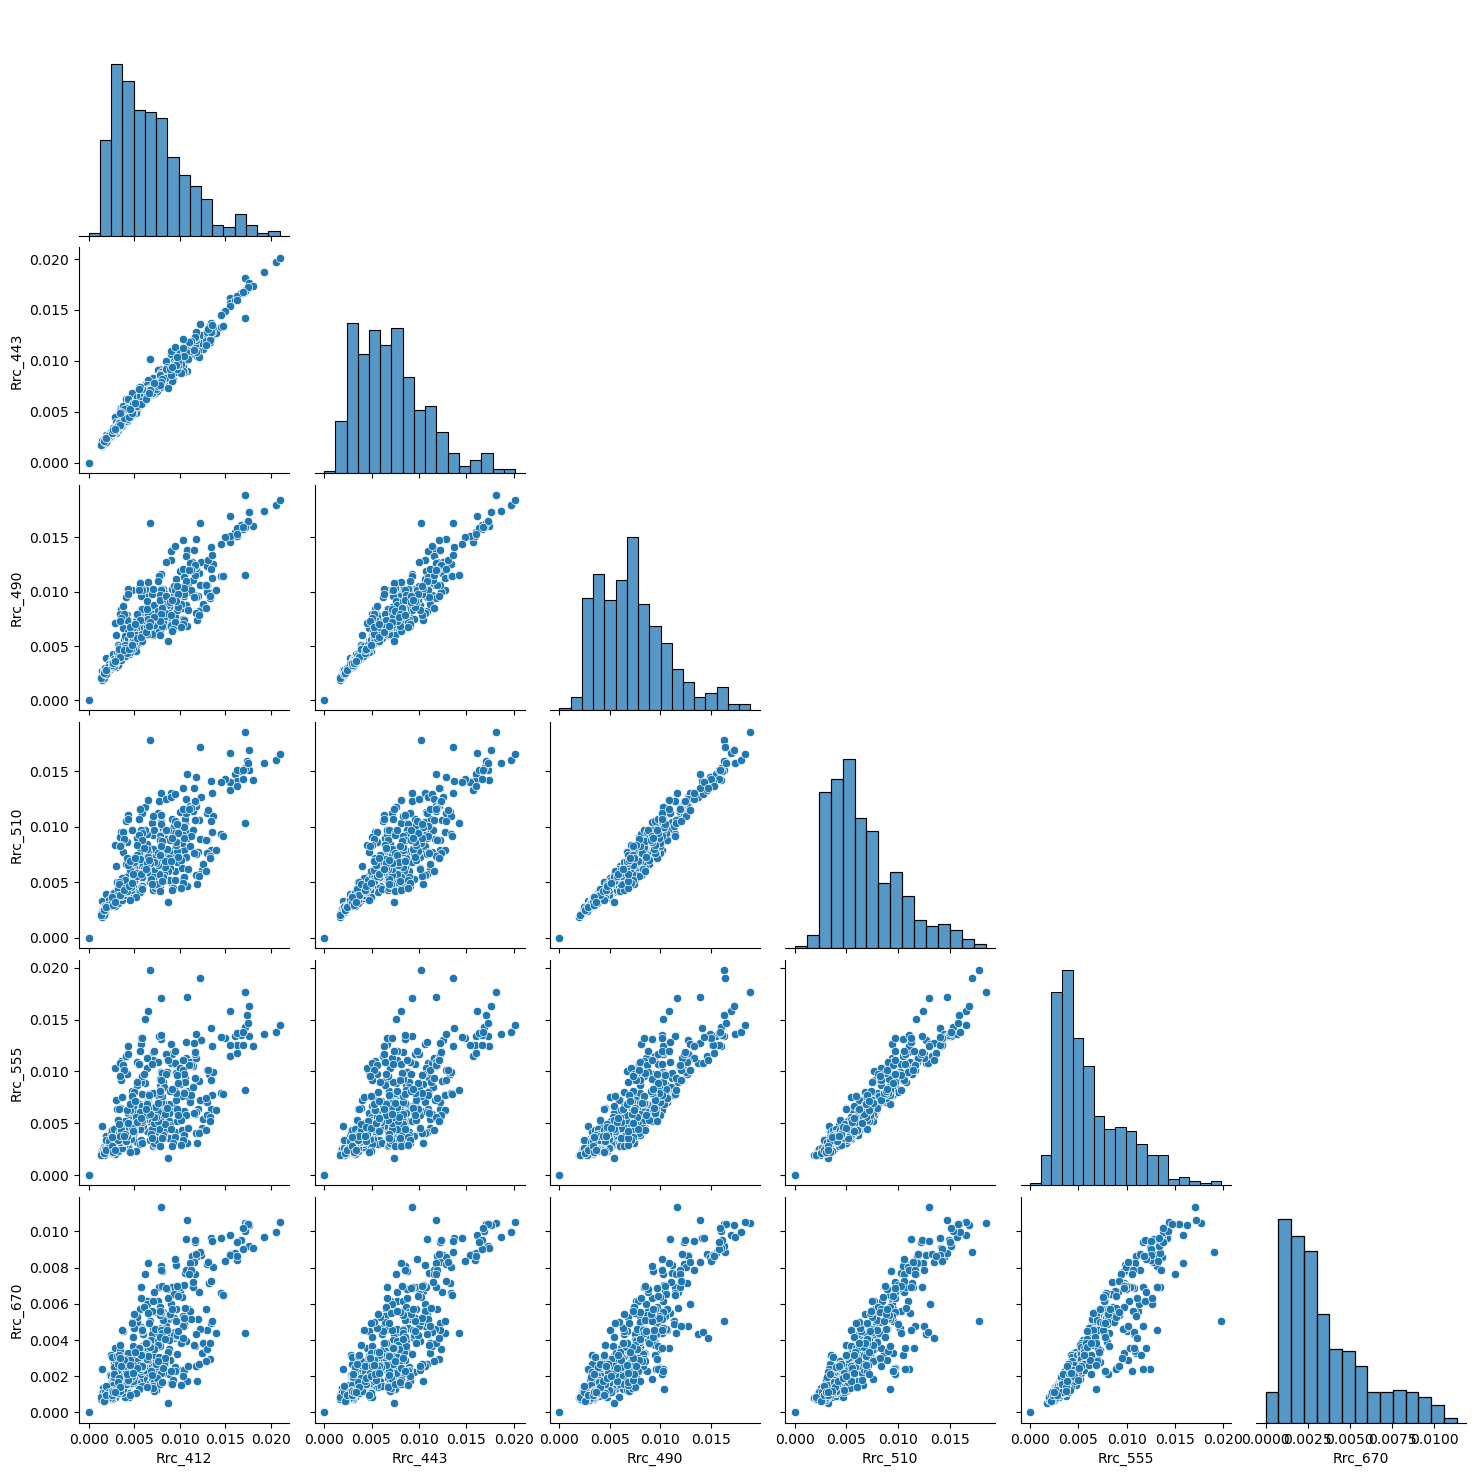

In [35]:
sb.pairplot(df_toa, corner=True)

In [36]:
df_chl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   chl        425 non-null    float64
 1   hplc_flag  496 non-null    object 
dtypes: float64(1), object(1)
memory usage: 7.9+ KB


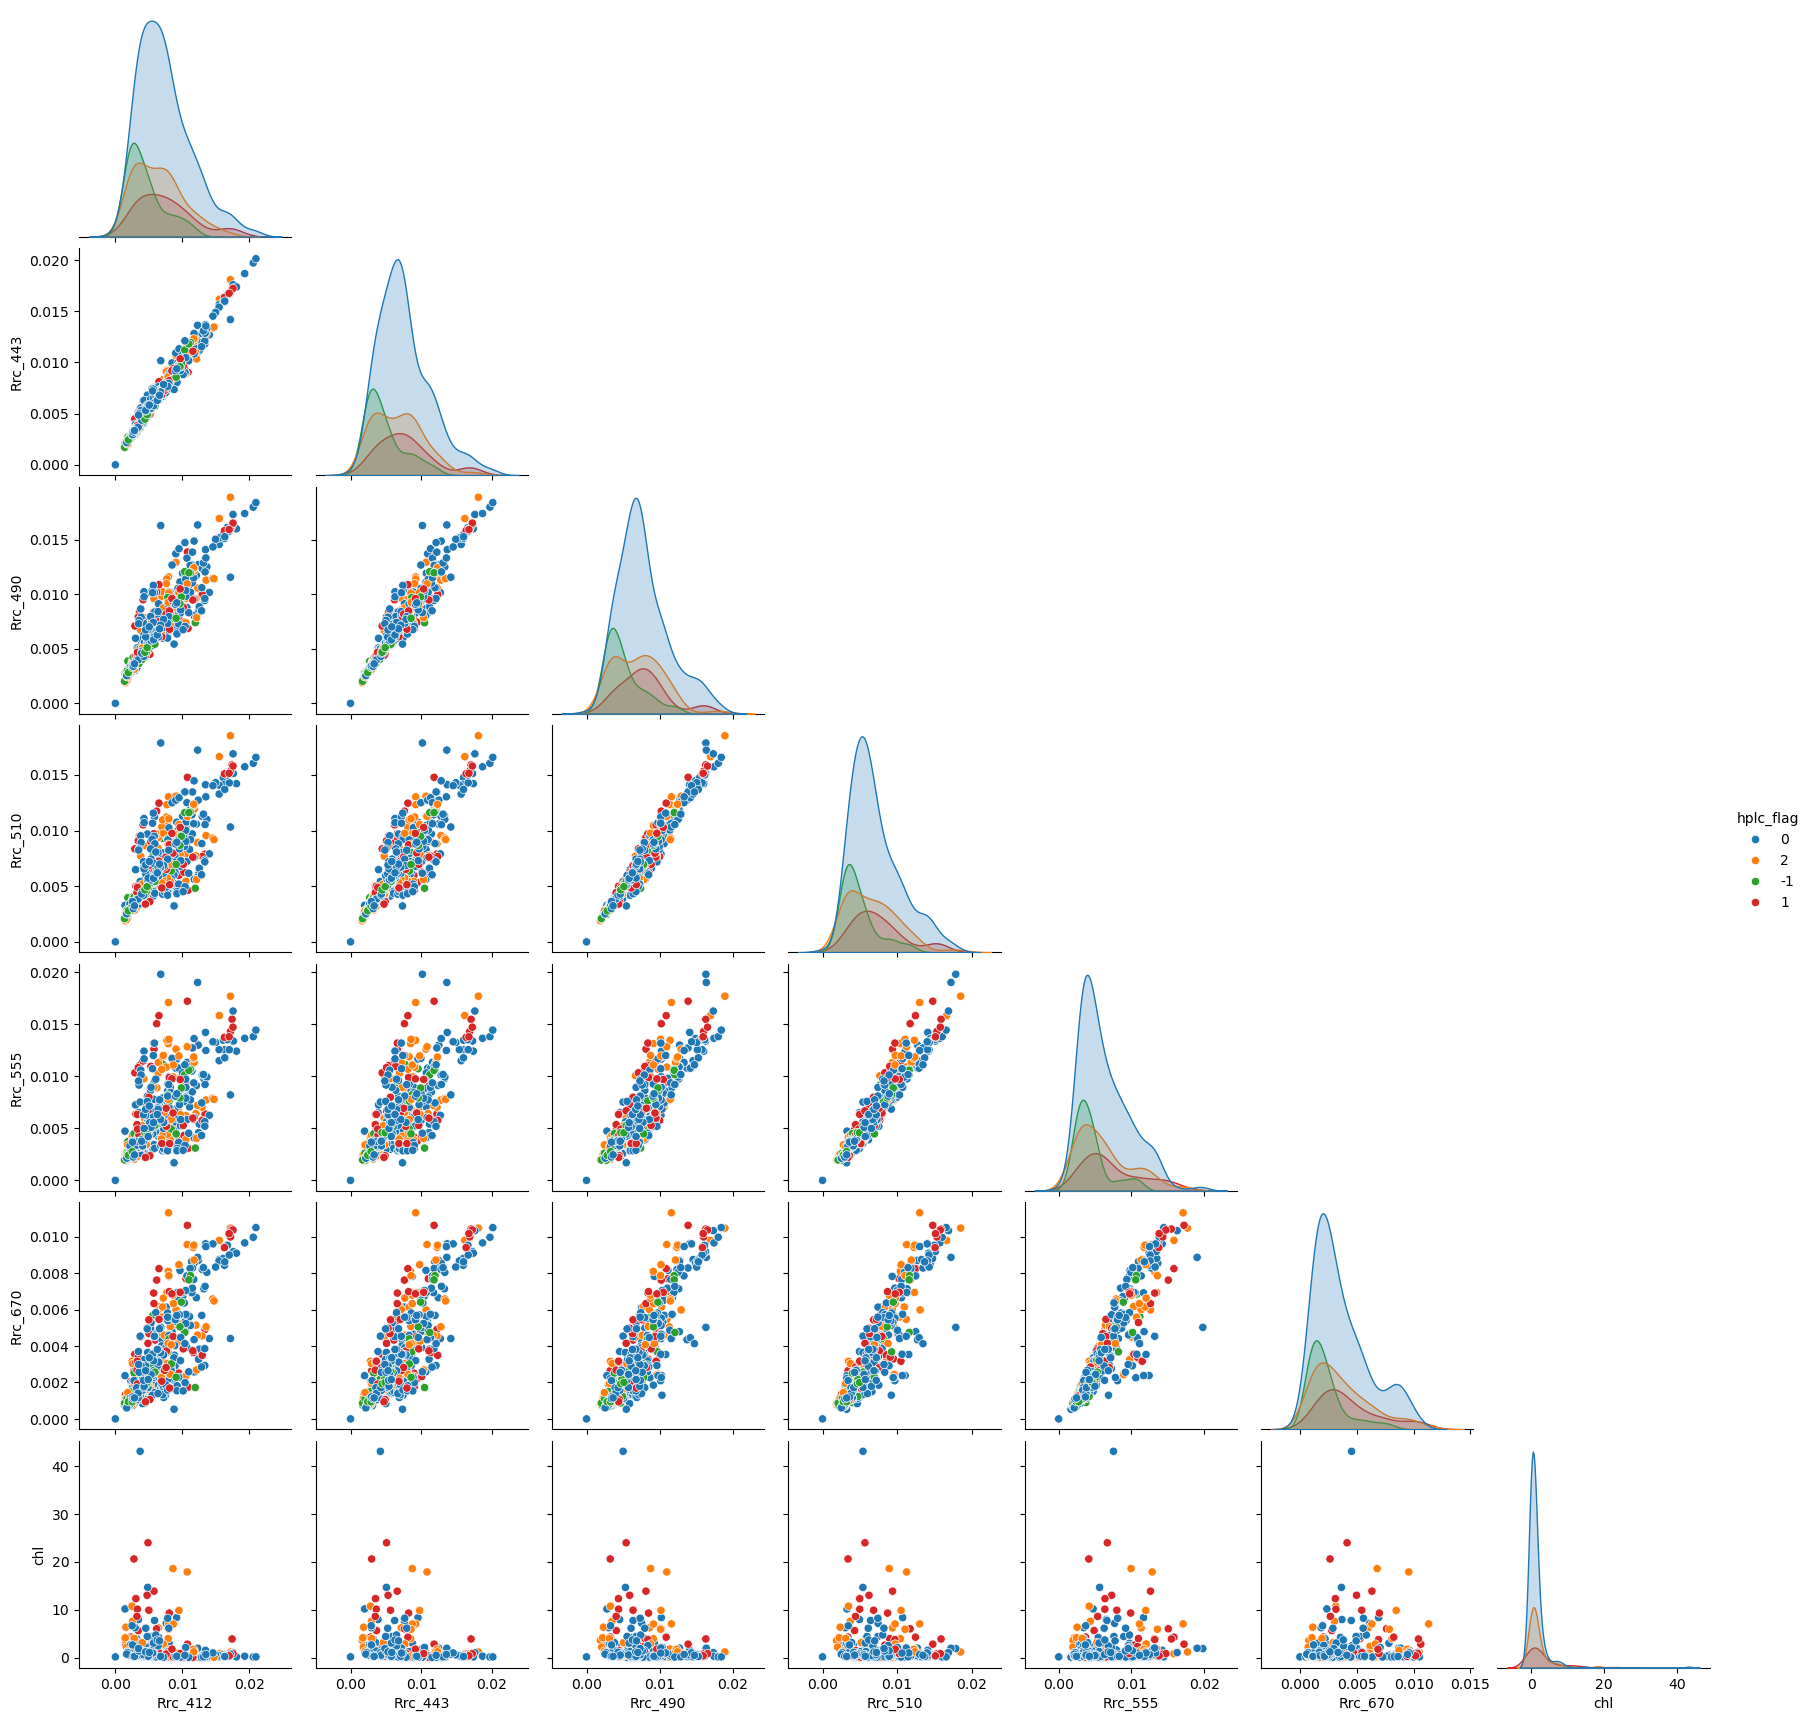

In [37]:
g=sb.pairplot(
    pd.concat((df_toa, df_chl), axis=1), hue='hplc_flag', corner=True)

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


<Axes: ylabel='Proportion'>

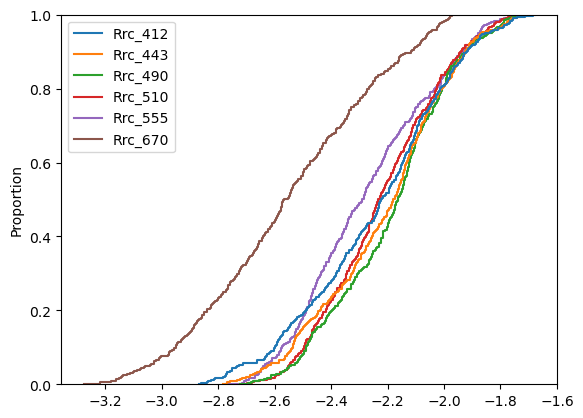

In [38]:
sb.ecdfplot(np.log10(df_toa.filter(like='Rrc_', axis='columns')))

In [39]:
df_chl.hplc_flag.value_counts()

hplc_flag
0     267
2      98
-1     71
1      60
Name: count, dtype: int64

In [40]:
df_aph.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   aph443  168 non-null    float64
 1   aph555  166 non-null    float64
 2   aph670  168 non-null    float64
dtypes: float64(3)
memory usage: 11.8 KB


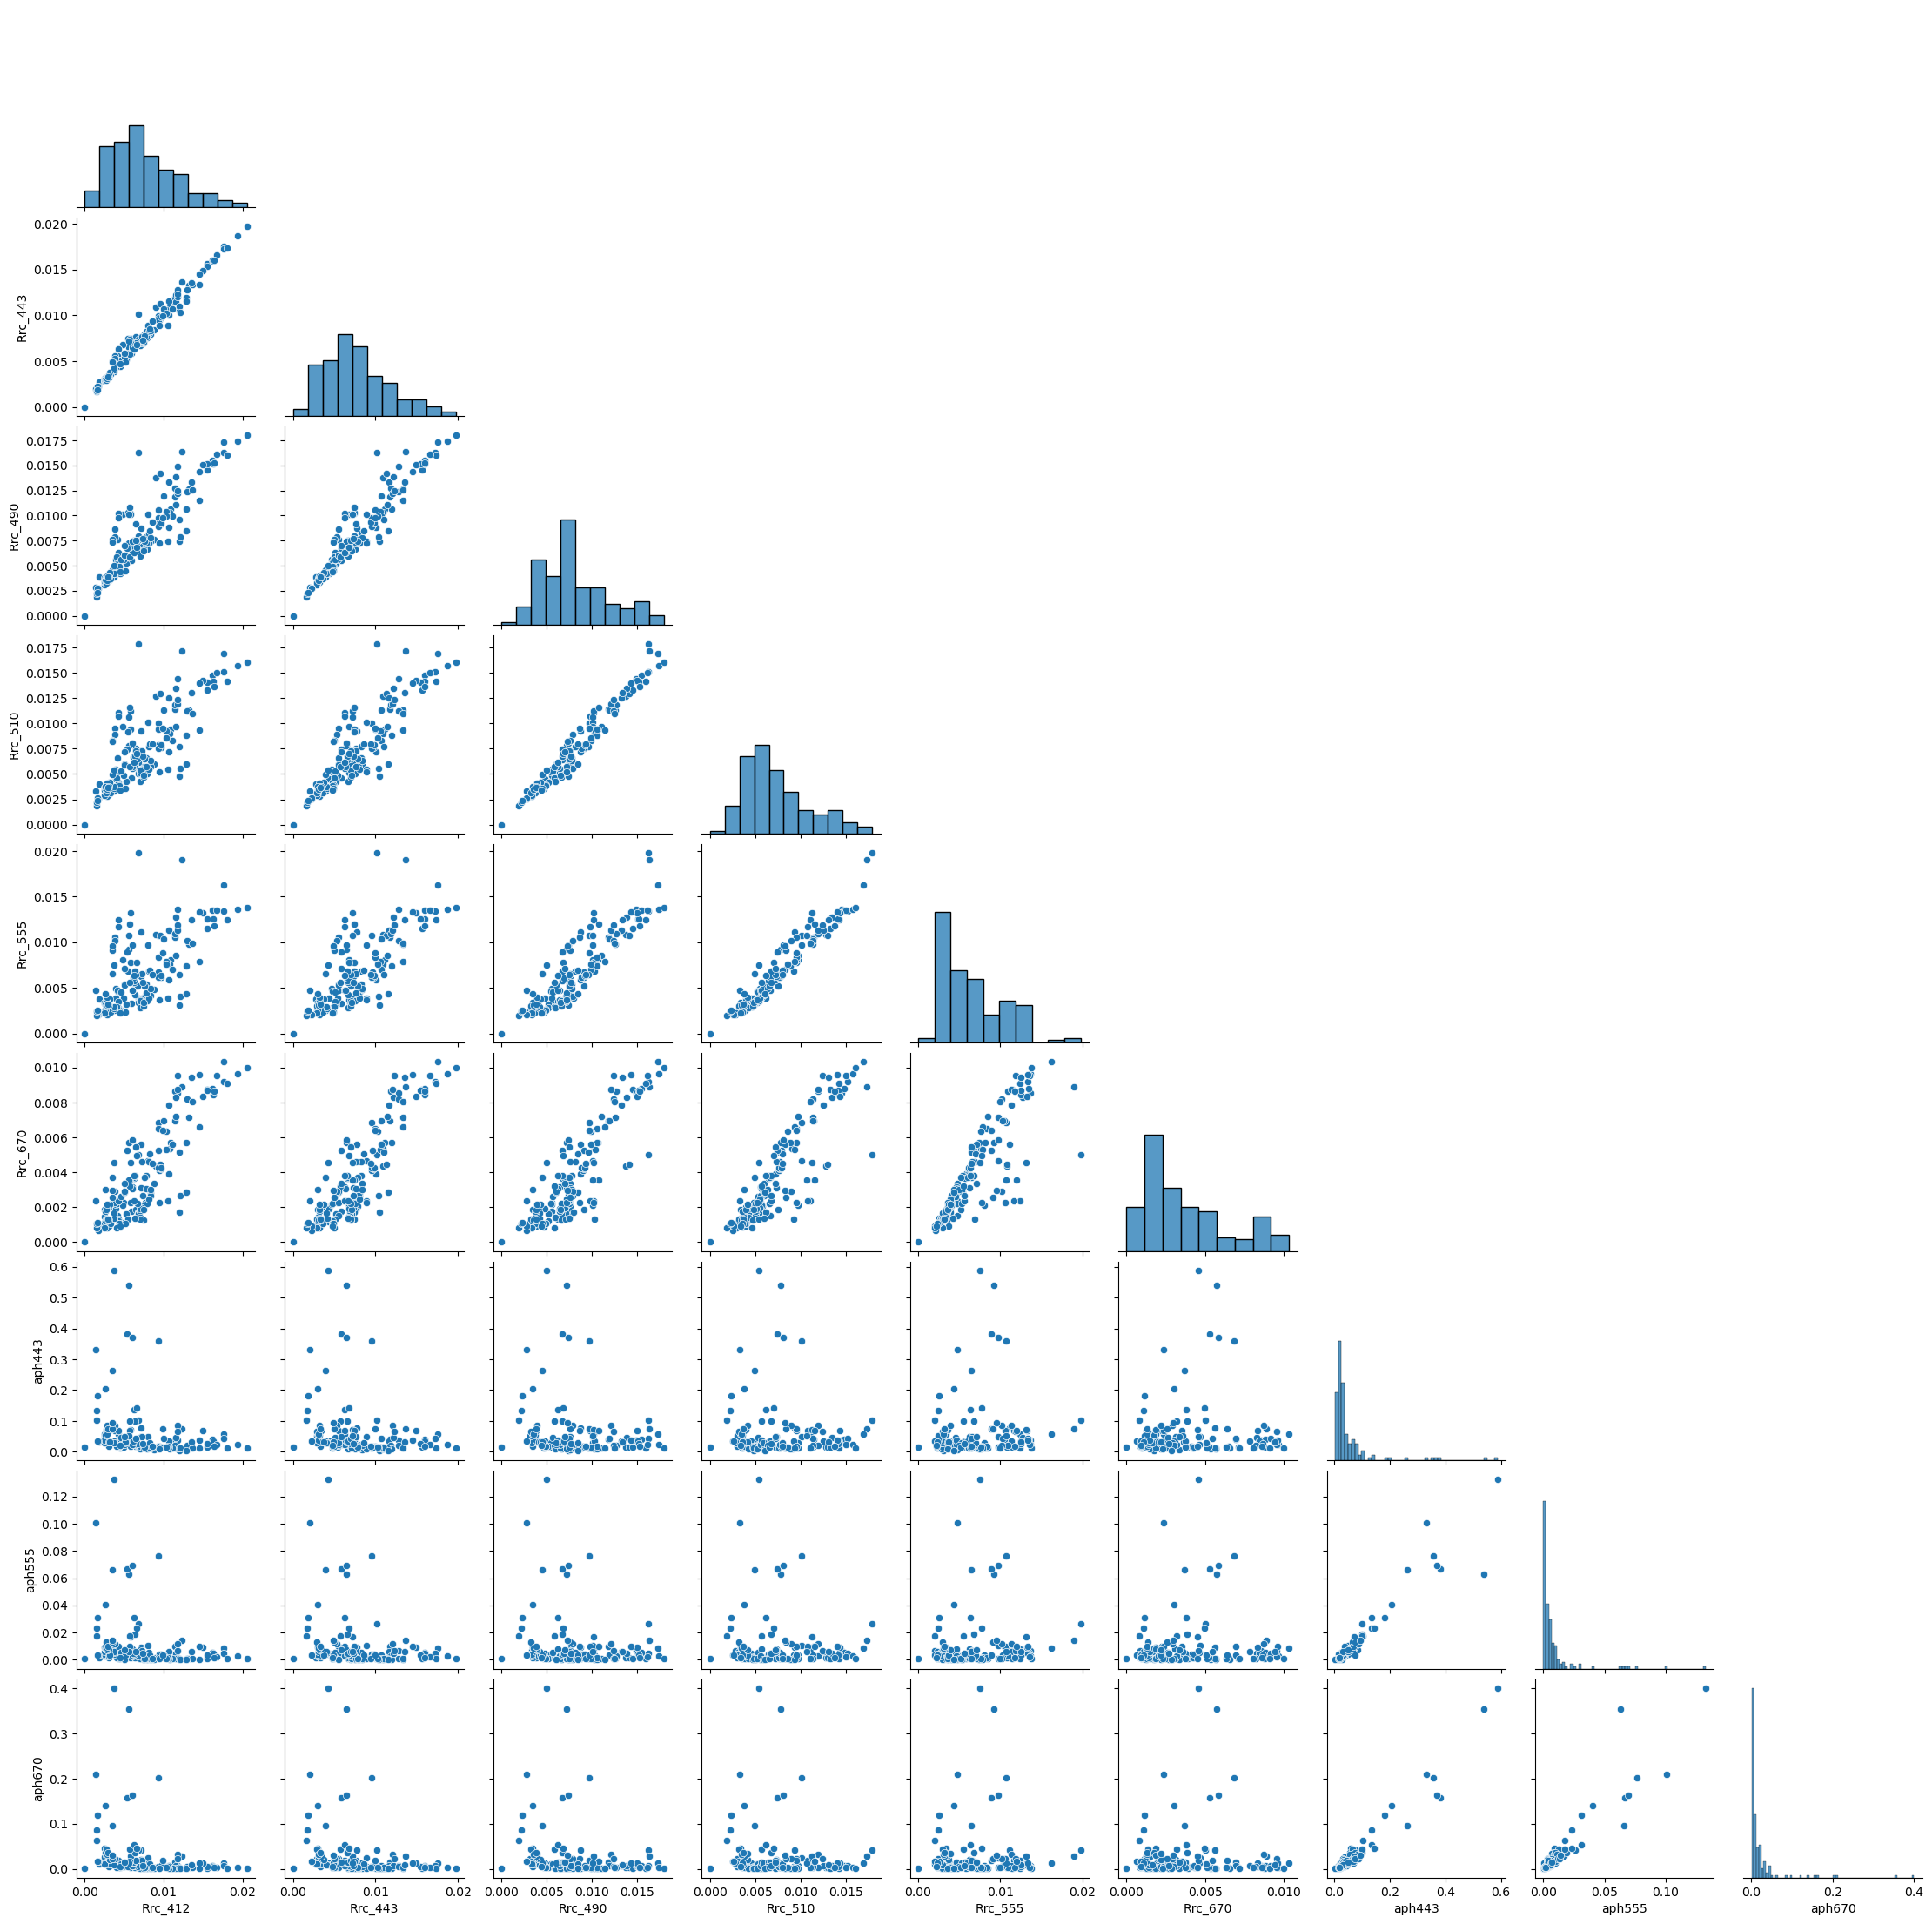

In [41]:
g = sb.pairplot(pd.merge(df_toa, df_aph, right_index=True, left_index=True).dropna(), corner=True)

In [42]:
df_all = pd.concat((df_toa, df_aph, df_chl), axis=1)

In [43]:
df_all.head()

,Rrc_412,Rrc_443,Rrc_490,Rrc_510,Rrc_555,Rrc_670,aph443,aph555,aph670,chl,hplc_flag
0,0.012088,0.012417,0.011739,0.010579,0.009110,0.006655,NaN,NaN,NaN,0.091,0
1,0.010525,0.010636,0.009614,0.007913,0.006224,0.004794,NaN,NaN,NaN,0.118,2
2,0.004443,0.004387,0.004240,0.003686,0.002646,0.001177,0.03078,0.00385,0.01040,NaN,-1
3,0.005869,0.005866,0.005535,0.004643,0.003326,0.001747,0.02283,0.00310,0.00935,0.614,2
4,0.009464,0.008968,0.007719,0.005974,0.004161,0.002517,NaN,NaN,NaN,0.158,1


In [44]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rrc_412    495 non-null    float64
 1   Rrc_443    495 non-null    float64
 2   Rrc_490    495 non-null    float64
 3   Rrc_510    495 non-null    float64
 4   Rrc_555    495 non-null    float64
 5   Rrc_670    495 non-null    float64
 6   aph443     168 non-null    float64
 7   aph555     166 non-null    float64
 8   aph670     168 non-null    float64
 9   chl        425 non-null    float64
 10  hplc_flag  496 non-null    object 
dtypes: float64(10), object(1)
memory usage: 42.8+ KB


In [45]:
df_all.describe()

,Rrc_412,Rrc_443,Rrc_490,Rrc_510,Rrc_555,Rrc_670,aph443,aph555,aph670,chl
count,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,168.000000,166.000000,168.000000,425.000000
mean,0.006742,0.007025,0.007243,0.006734,0.006170,0.003537,0.052049,0.008388,0.022144,1.633998
std,0.003876,0.003640,0.003453,0.003350,0.003526,0.002458,0.083250,0.017446,0.050978,3.519893
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002560,0.000000,0.000560,0.025000
25%,0.003706,0.004168,0.004514,0.004123,0.003430,0.001666,0.016860,0.001155,0.002818,0.198100
50%,0.005988,0.006625,0.006866,0.005819,0.005138,0.002724,0.027900,0.003295,0.006675,0.535410
75%,0.008865,0.008941,0.009144,0.008748,0.007997,0.004723,0.050157,0.007593,0.019030,1.385200
max,0.020979,0.020130,0.018906,0.018512,0.019804,0.011320,0.587770,0.132730,0.400580,43.100000


In [18]:
df_log = df_all.drop('hplc_flag', axis=1).replace(0, np.nan).transform(np.log10)

In [47]:
df_aph = df_all.drop(['hplc_flag', 'chl'], axis=1).replace(0, np.nan)

In [48]:
df_aph.head()

,Rrc_412,Rrc_443,Rrc_490,Rrc_510,Rrc_555,Rrc_670,aph443,aph555,aph670
0,0.012088,0.012417,0.011739,0.010579,0.009110,0.006655,NaN,NaN,NaN
1,0.010525,0.010636,0.009614,0.007913,0.006224,0.004794,NaN,NaN,NaN
2,0.004443,0.004387,0.004240,0.003686,0.002646,0.001177,0.03078,0.00385,0.01040
3,0.005869,0.005866,0.005535,0.004643,0.003326,0.001747,0.02283,0.00310,0.00935
4,0.009464,0.008968,0.007719,0.005974,0.004161,0.002517,NaN,NaN,NaN


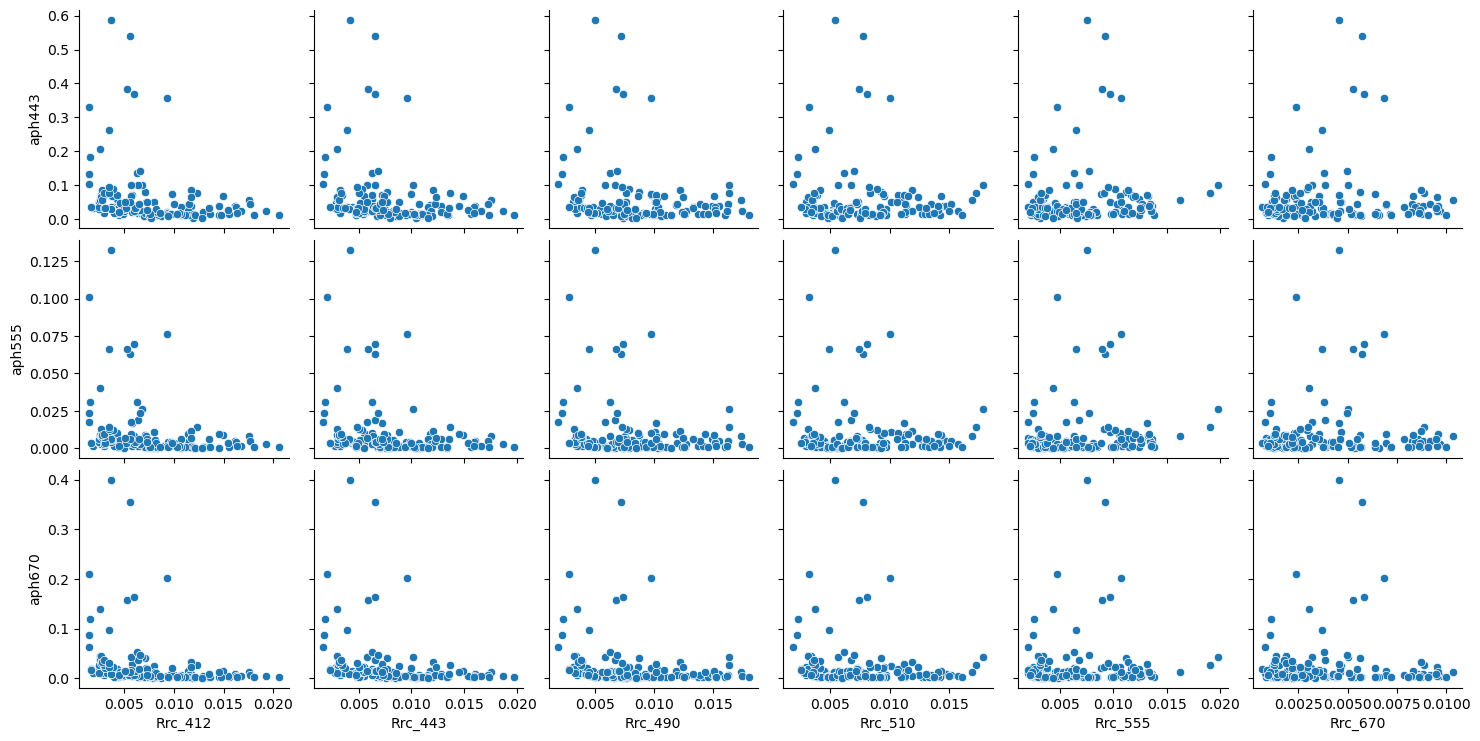

In [ ]:
xvars= df_aph.filter(like='Rrc').columns.to_list()
yvars = df_aph.filter(like='aph').columns.to_list()
f, ax = pp.subplots()
sb.pairplot(
    df_aph, x_vars=xvars, y_vars=yvars)

,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,log_Rrc_555,log_Rrc_670,log_aph443,log_aph555,log_aph670,log_chl,hplc_flag
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,NaN,NaN,NaN,-1.040959,0
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,NaN,NaN,NaN,-0.928118,2
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,-1.511731,-2.414539,-1.982967,NaN,-1
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-1.641494,-2.508638,-2.029188,-0.211832,2
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,NaN,NaN,NaN,-0.801343,1


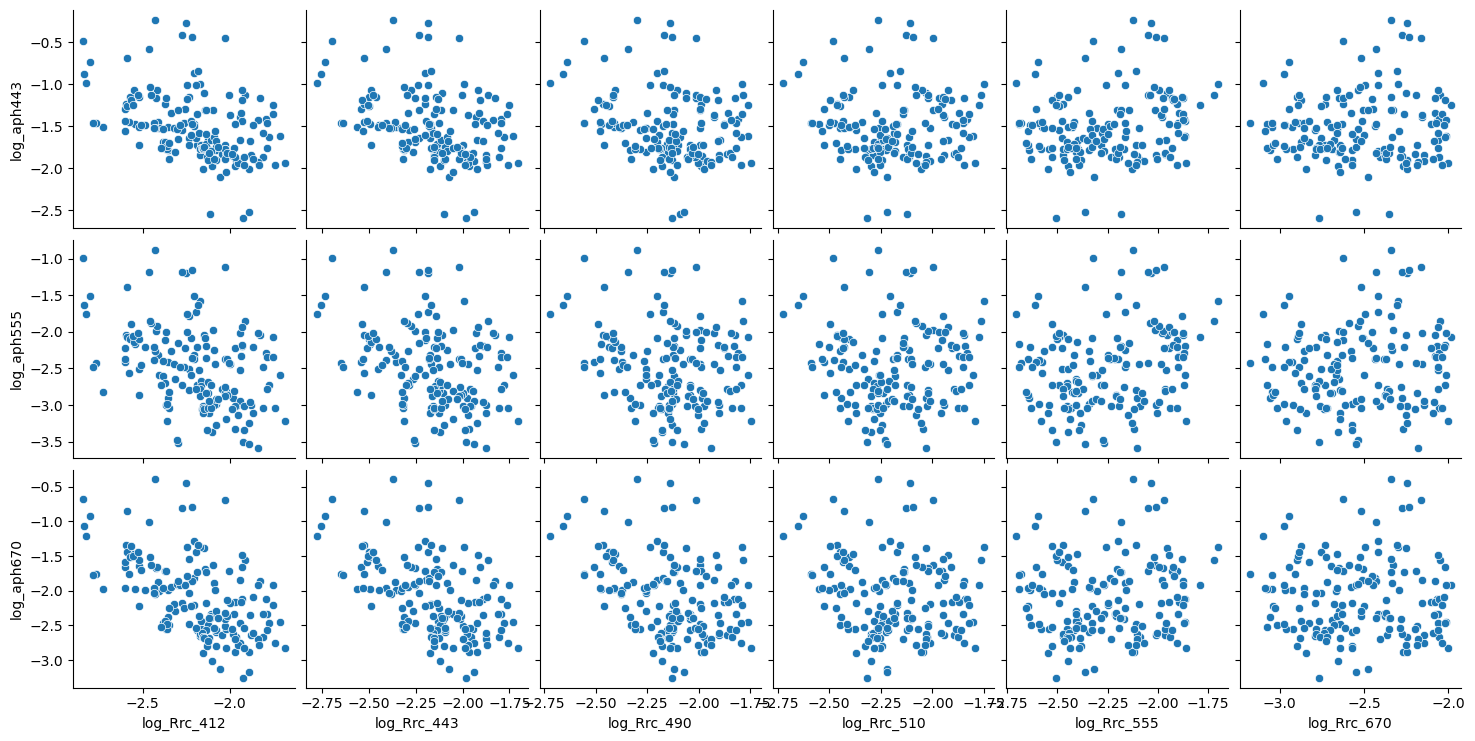

In [53]:
log_xvars = df_log.filter(like='Rrc').columns.to_list()
log_yvars = df_log.filter(like='aph').columns.to_list()
sb.pairplot(df_log, x_vars=log_xvars, y_vars=log_yvars)

In [65]:
df_log.columns.to_list()

['log_Rrc_412',
 'log_Rrc_443',
 'log_Rrc_490',
 'log_Rrc_510',
 'log_Rrc_555',
 'log_Rrc_670',
 'log_aph443',
 'log_aph555',
 'log_aph670',
 'log_chl',
 'hplc_flag']

In [66]:
df_final = pd.merge(df_log.drop('hplc_flag', axis=1), df_all, right_index=True, left_index=True, )#df_final.merge(df_all[['hplc_flag']])

In [67]:
df_final.columns.to_list()

['log_Rrc_412',
 'log_Rrc_443',
 'log_Rrc_490',
 'log_Rrc_510',
 'log_Rrc_555',
 'log_Rrc_670',
 'log_aph443',
 'log_aph555',
 'log_aph670',
 'log_chl',
 'Rrc_412',
 'Rrc_443',
 'Rrc_490',
 'Rrc_510',
 'Rrc_555',
 'Rrc_670',
 'aph443',
 'aph555',
 'aph670',
 'chl',
 'hplc_flag']

In [74]:
x_vars = sorted(df_final.filter(like='Rrc').columns.to_list())
y_vars = sorted(df_final.filter(regex='aph').columns.to_list())
y_vars += ['chl', 'log_chl', 'hplc_flag']
df_final = df_final.loc[:, x_vars+y_vars]

In [75]:
df_final.head()

,Rrc_412,Rrc_443,Rrc_490,Rrc_510,Rrc_555,Rrc_670,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,...,log_Rrc_670,aph443,aph555,aph670,log_aph443,log_aph555,log_aph670,chl,log_chl,hplc_flag
0,0.012088,0.012417,0.011739,0.010579,0.009110,0.006655,-1.917660,-1.905994,-1.930380,-1.975543,...,-2.176858,NaN,NaN,NaN,NaN,NaN,NaN,0.091,-1.040959,0
1,0.010525,0.010636,0.009614,0.007913,0.006224,0.004794,-1.977774,-1.973214,-2.017116,-2.101675,...,-2.319302,NaN,NaN,NaN,NaN,NaN,NaN,0.118,-0.928118,2
2,0.004443,0.004387,0.004240,0.003686,0.002646,0.001177,-2.352334,-2.357865,-2.372588,-2.433492,...,-2.929113,0.03078,0.00385,0.01040,-1.511731,-2.414539,-1.982967,NaN,NaN,-1
3,0.005869,0.005866,0.005535,0.004643,0.003326,0.001747,-2.231428,-2.231674,-2.256908,-2.333192,...,-2.757732,0.02283,0.00310,0.00935,-1.641494,-2.508638,-2.029188,0.614,-0.211832,2
4,0.009464,0.008968,0.007719,0.005974,0.004161,0.002517,-2.023925,-2.047304,-2.112433,-2.223764,...,-2.599169,NaN,NaN,NaN,NaN,NaN,NaN,0.158,-0.801343,1


In [56]:
df_log.describe()

,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,log_Rrc_555,log_Rrc_670,log_aph443,log_aph555,log_aph670,log_chl,hplc_flag
count,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,168.000000,165.000000,168.000000,425.000000,496.000000
mean,-2.243752,-2.211681,-2.188250,-2.221014,-2.273265,-2.552109,-1.515120,-2.485220,-2.096915,-0.240156,0.372984
std,0.261270,0.233448,0.210712,0.209085,0.234739,0.302959,0.399355,0.559151,0.563594,0.605643,0.957689
min,-2.866391,-2.780822,-2.722008,-2.723630,-2.772216,-3.274987,-2.591760,-3.585027,-3.251812,-1.602060,-1.000000
25%,-2.428765,-2.375724,-2.344104,-2.383034,-2.464339,-2.774131,-1.773151,-2.920819,-2.550137,-0.703116,0.000000
50%,-2.221946,-2.177449,-2.163120,-2.231877,-2.289159,-2.561220,-1.554398,-2.480172,-2.175559,-0.271314,0.000000
75%,-2.052141,-2.048511,-2.038700,-2.057387,-2.096901,-2.324630,-1.299665,-2.112946,-1.720566,0.141512,1.000000
max,-1.678213,-1.696152,-1.723400,-1.732540,-1.703243,-1.946138,-0.230793,-0.877031,-0.397311,1.634477,2.000000


In [20]:
df_log.rename(columns={col: f'log_{col}' for col in df_log.columns}, inplace=True)

In [21]:
df_log['hplc_flag'] = df_all.hplc_flag.astype('int8')

In [22]:
df_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_Rrc_412  494 non-null    float64
 1   log_Rrc_443  494 non-null    float64
 2   log_Rrc_490  494 non-null    float64
 3   log_Rrc_510  494 non-null    float64
 4   log_Rrc_555  494 non-null    float64
 5   log_Rrc_670  494 non-null    float64
 6   log_aph443   168 non-null    float64
 7   log_aph555   165 non-null    float64
 8   log_aph670   168 non-null    float64
 9   log_chl      425 non-null    float64
 10  hplc_flag    496 non-null    int8   
dtypes: float64(10), int8(1)
memory usage: 39.4 KB


In [23]:
df_log.hplc_flag.value_counts()

hplc_flag
 0    267
 2     98
-1     71
 1     60
Name: count, dtype: int64

In [24]:
df_log.head()

,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,log_Rrc_555,log_Rrc_670,log_aph443,log_aph555,log_aph670,log_chl,hplc_flag
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,NaN,NaN,NaN,-1.040959,0
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,NaN,NaN,NaN,-0.928118,2
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,-1.511731,-2.414539,-1.982967,NaN,-1
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-1.641494,-2.508638,-2.029188,-0.211832,2
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,NaN,NaN,NaN,-0.801343,1


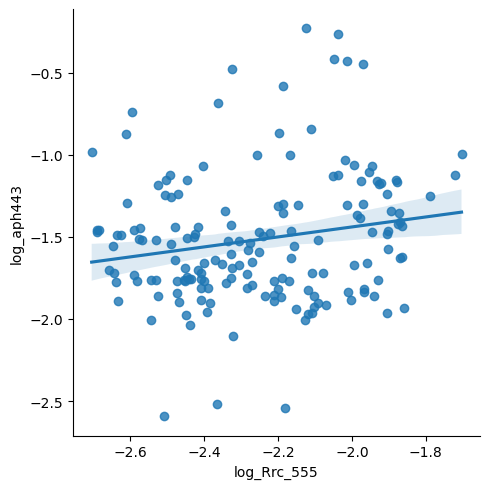

In [ ]:
sb.lmplot(df_log, x='log_Rrc_555', y='log_aph443')

In [78]:
y_vars

['aph443',
 'aph555',
 'aph670',
 'log_aph443',
 'log_aph555',
 'log_aph670',
 'chl',
 'log_chl',
 'hplc_flag']

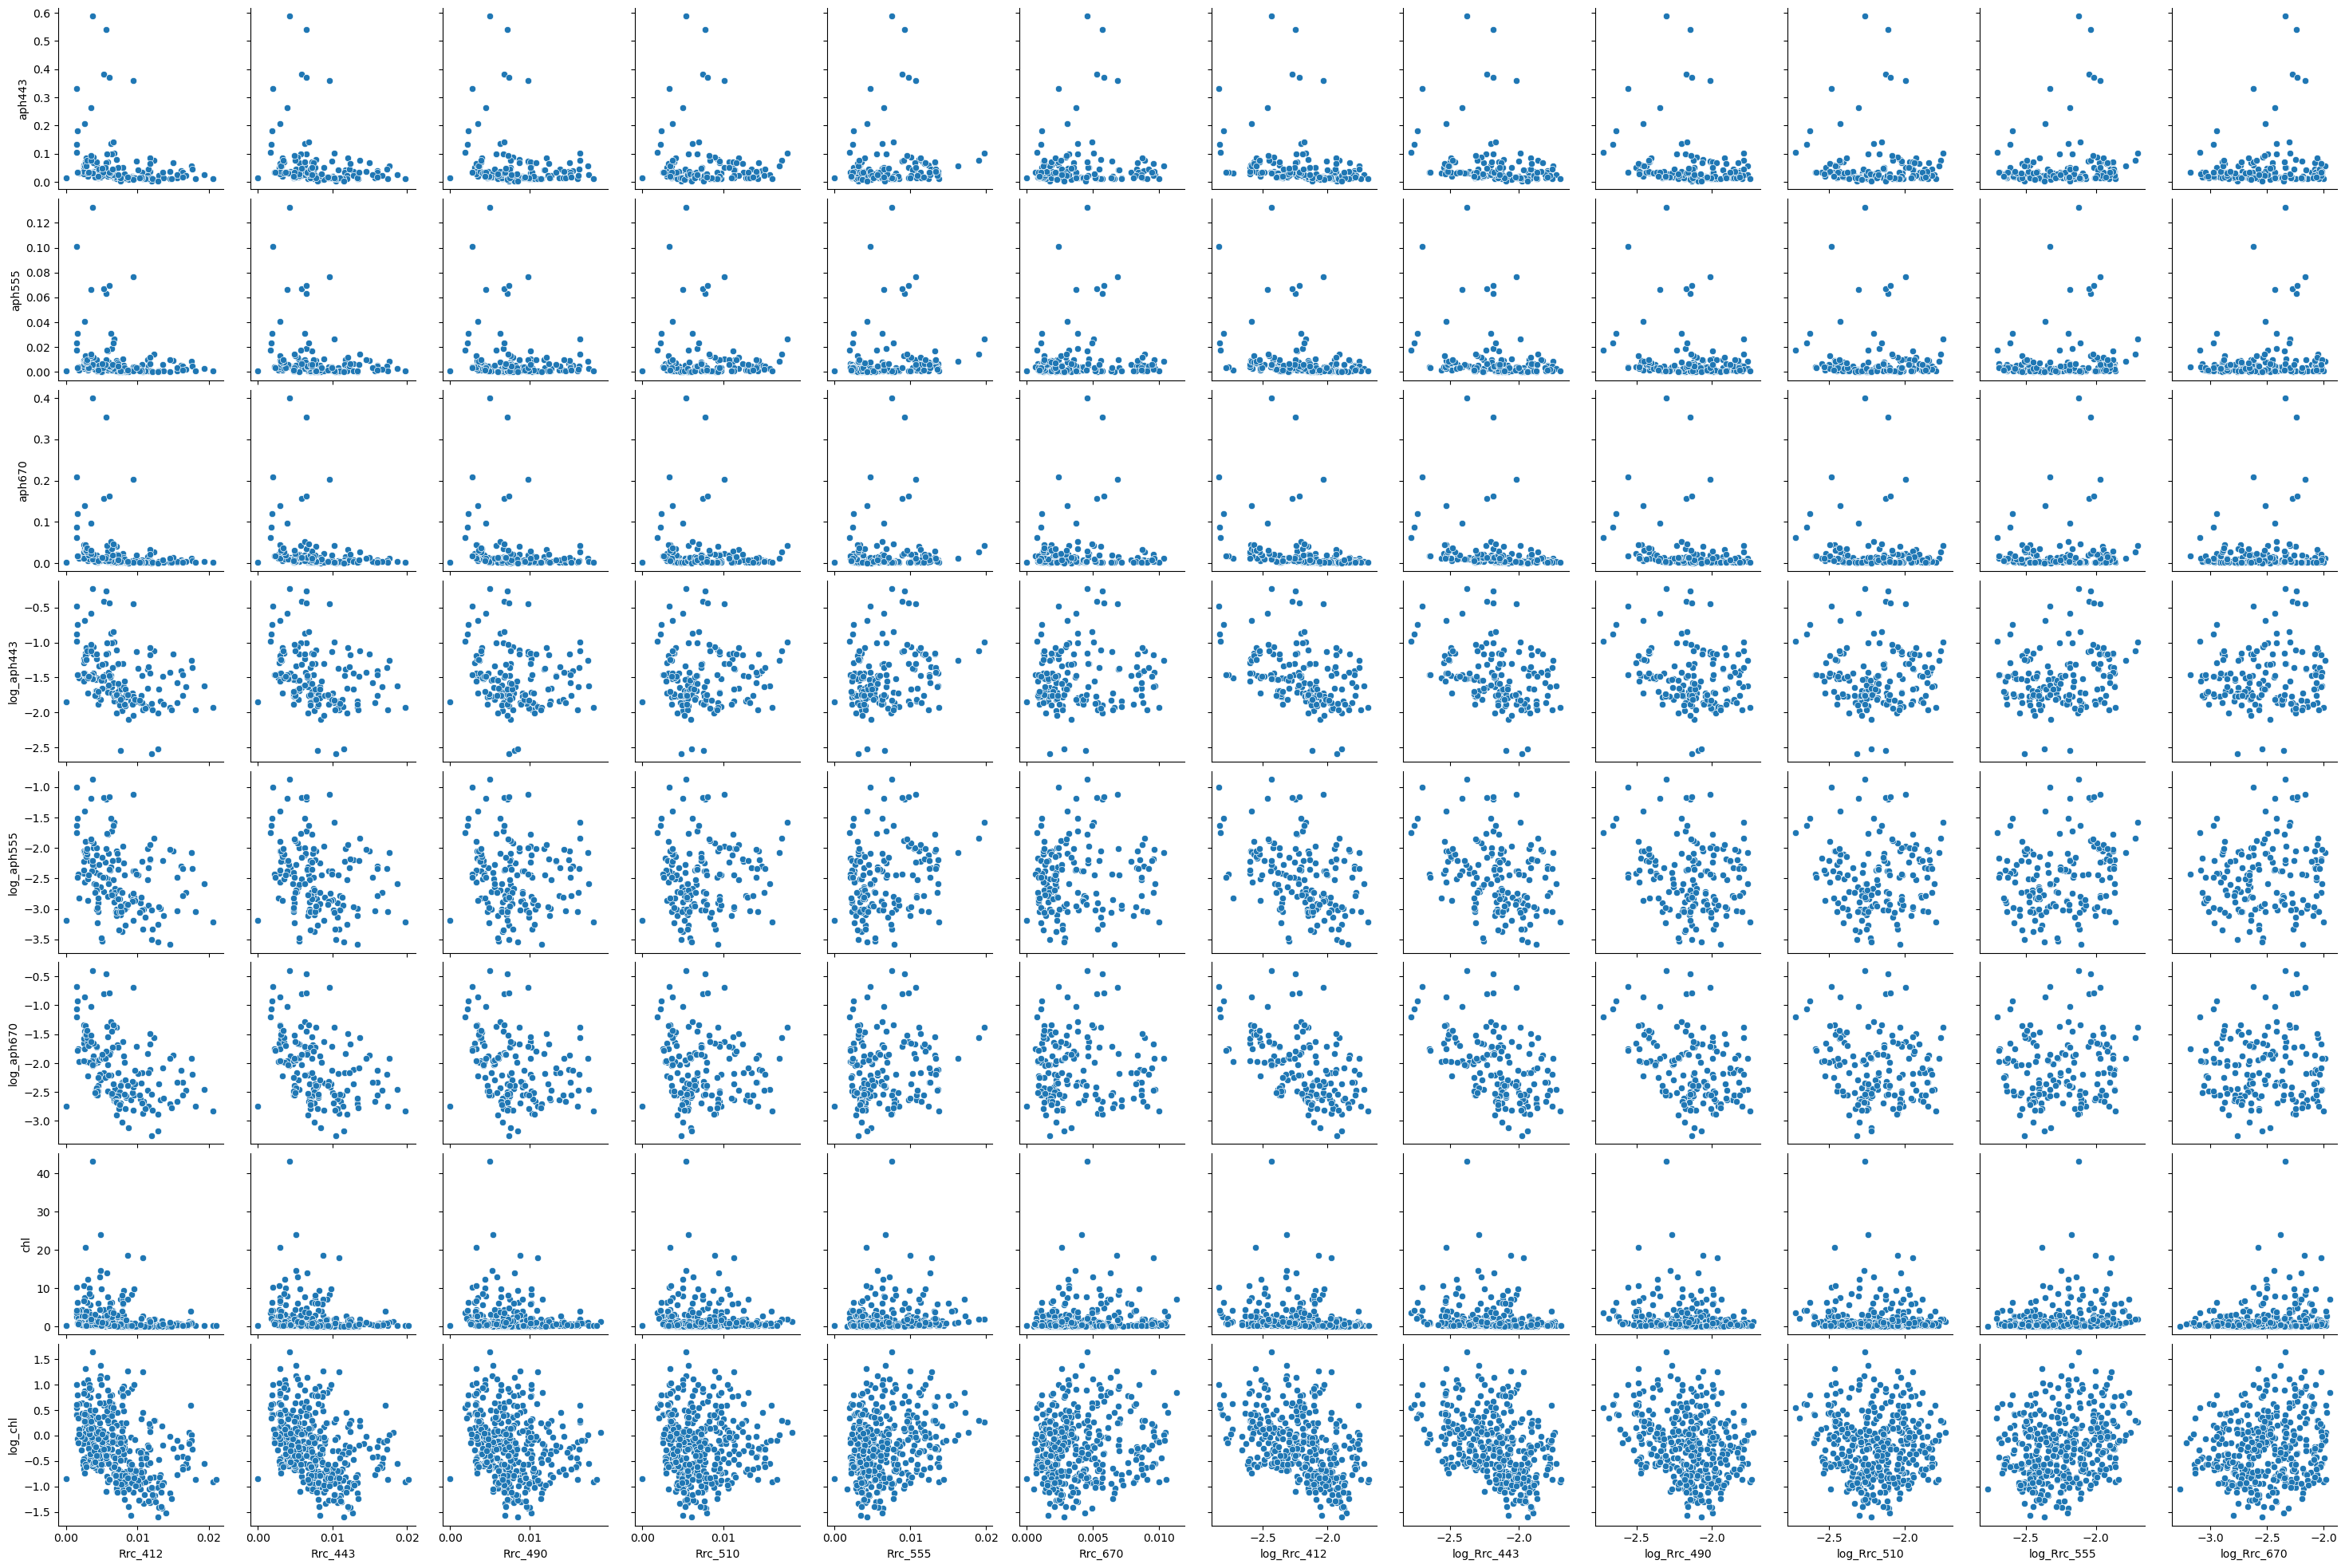

In [79]:
sb.pairplot(df_final, x_vars=x_vars, y_vars=y_vars[:-1])

In [ ]:
input_cols = df_log.filter(like='Rrc').columns
target_cols = df_log.filter(regex='aph|chl').columns


In [ ]:
df_log[target_cols]

,log_aph443,log_aph555,log_aph670,log_chl
0,NaN,NaN,NaN,-1.040959
1,NaN,NaN,NaN,-0.928118
2,-1.511731,-2.414539,-1.982967,NaN
3,-1.641494,-2.508638,-2.029188,-0.211832
4,NaN,NaN,NaN,-0.801343
...,...,...,...,...
491,NaN,NaN,NaN,0.072893
492,-0.845667,-1.628194,-1.336959,0.542789
493,NaN,NaN,NaN,-0.327948
494,-1.308830,-2.156767,-1.853872,0.030183


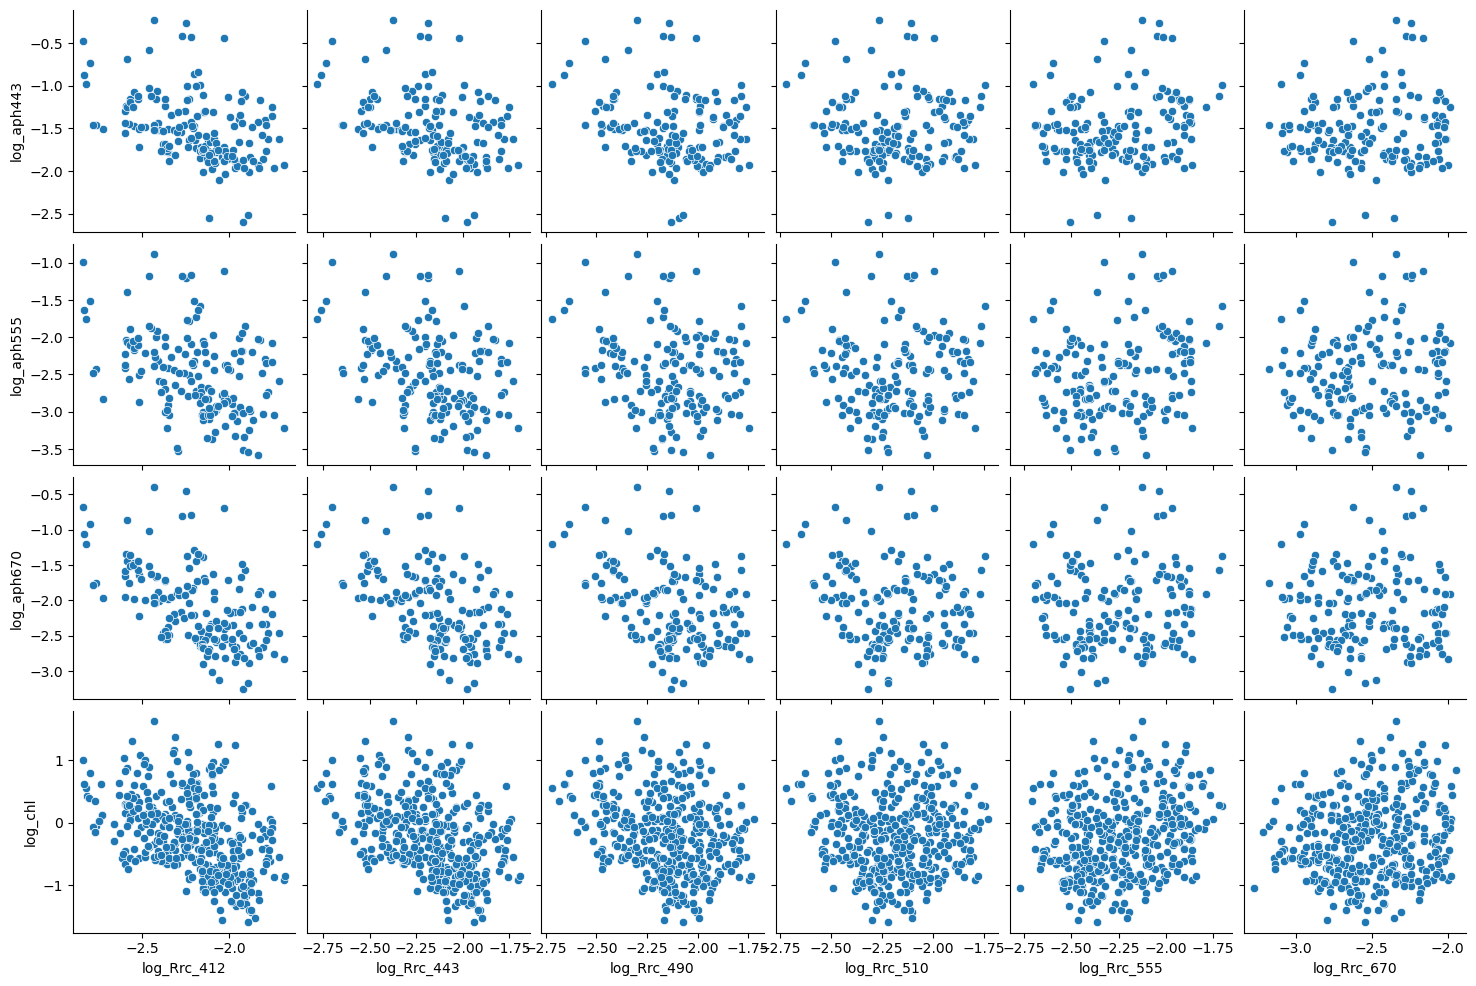

In [ ]:
sb.pairplot(df_log.select_dtypes('float'), 
            x_vars=input_cols.to_list(), 
            y_vars=target_cols.to_list(), 
           )

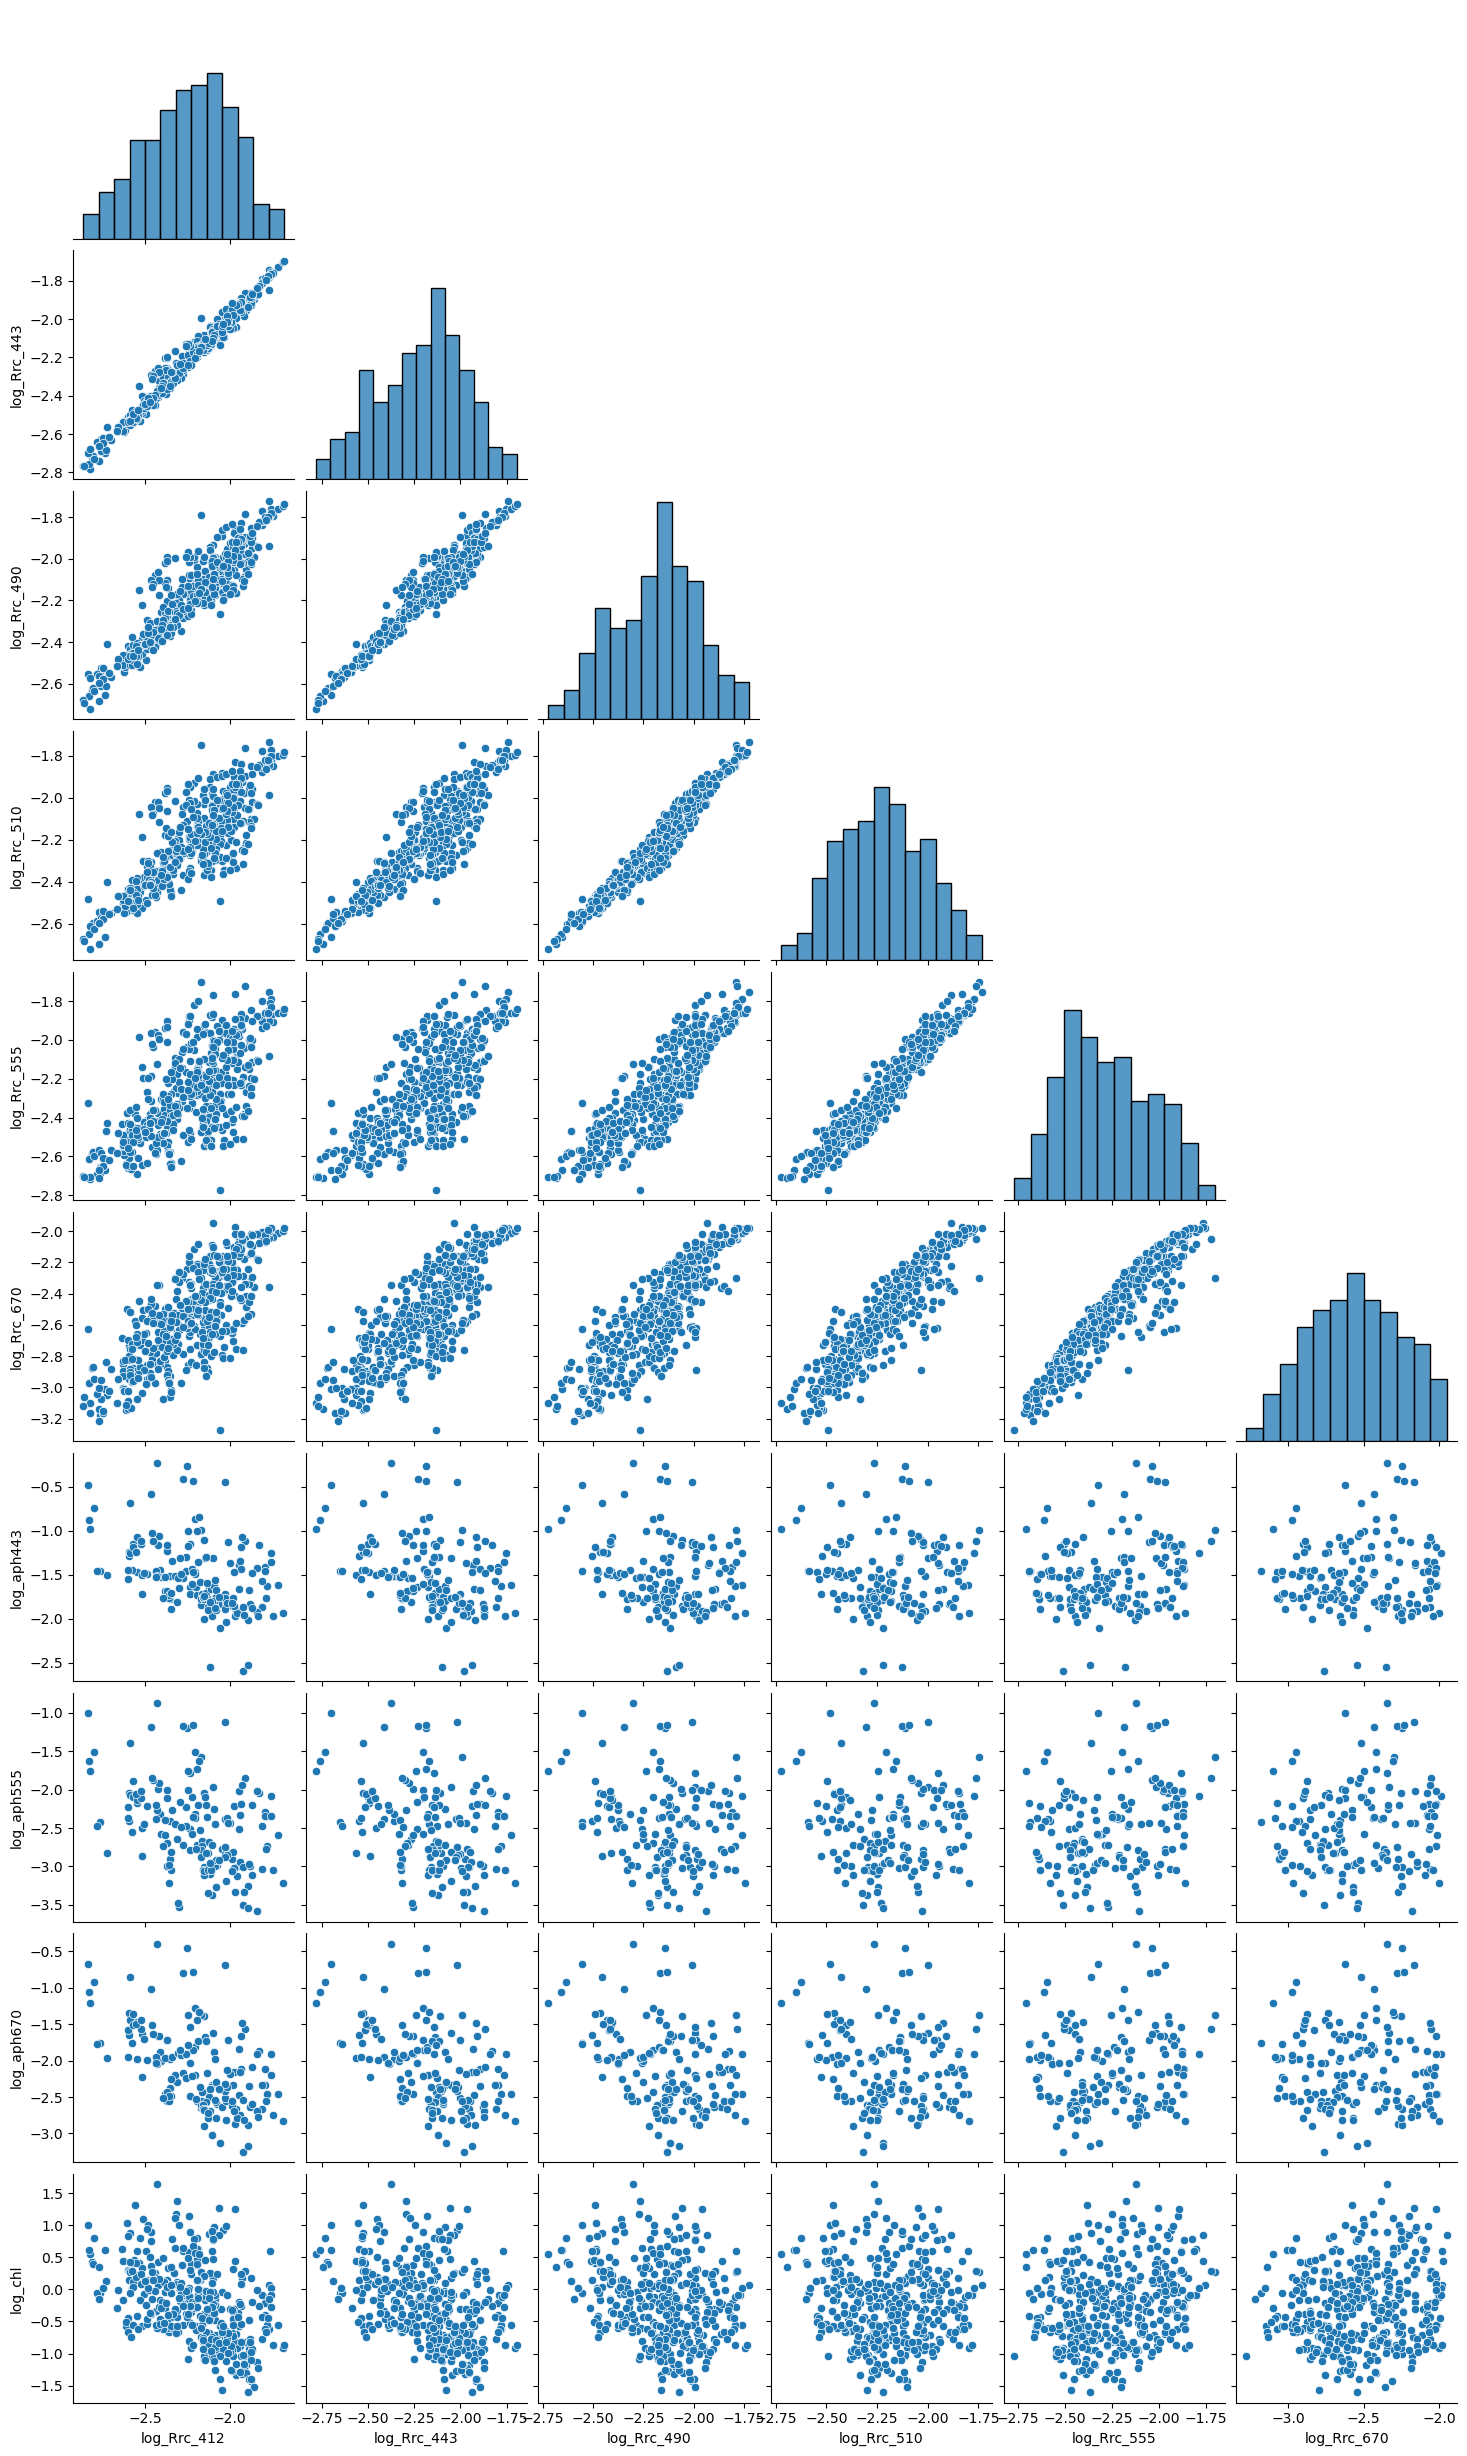

In [ ]:

sb.pairplot(df_log.select_dtypes('float'), 
            x_vars=input_cols.to_list(), 
            y_vars=target_cols.to_list(), 
            corner=True,)

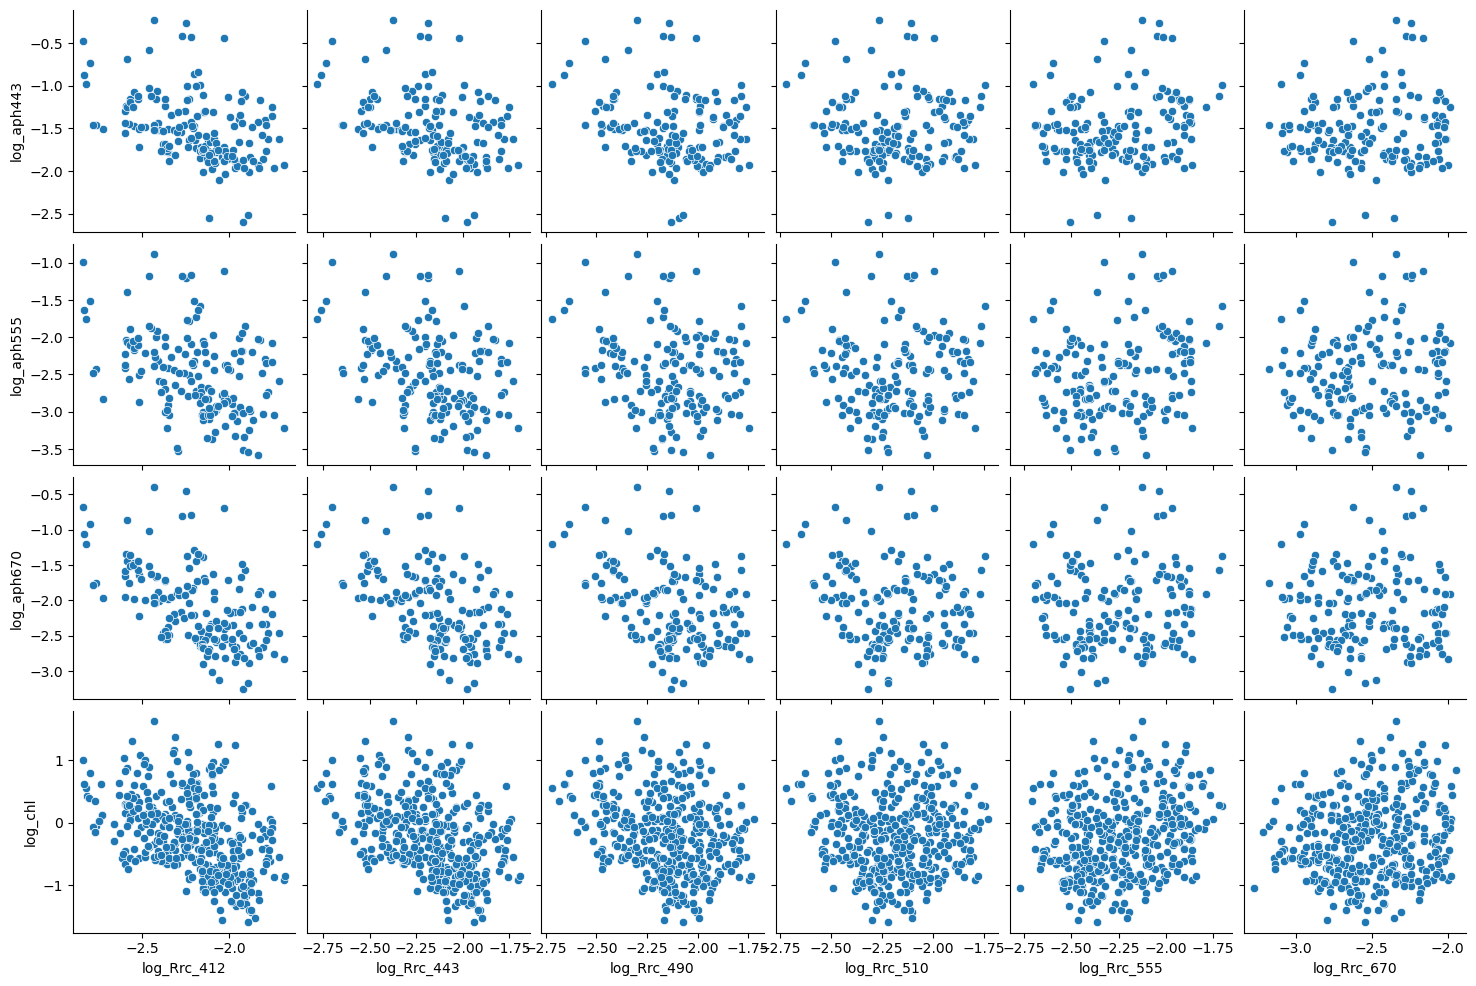

In [ ]:

sb.pairplot(df_log.select_dtypes('float'), 
            x_vars=input_cols.to_list(), 
            y_vars=target_cols.to_list(), 
            #corner=True,
            )

In [ ]:
df_log.to_parquet(data_path / '03_transformed/df_log.pqt')

In [80]:
df_final.to_parquet(data_path / '03_transformed/df_all.pqt')